# Lineární regrese – Cvičení 1 (Linear Regression – Exercise 1)
**Dataset:** Real estate prices in King County, USA (`kc_house_data.csv`)

---

### Zadání / Assignment:
1. Přeneste datový soubor `kc_house_data.csv` o nemovitostech v King County do běhového prostředí.
2. Importujte všechny potřebné metody a moduly z knihoven (`pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`).
3. Načtěte data do Pandas DataFrame a uložte do proměnné `housing_df`.
4. Zobrazte prvních cca 15 záznamů pro seznámení se s daty.
5. Odstraňte nepotřebné sloupce z datové sady (`id`, `date`).
6. Pomocí naučených metod ověřte přítomnost chybějících hodnot (missing values).
7. Vygenerujte a vizualizujte korelační matici. Graficky ověřte linearitu vybraných proměnných s cenou (`price`).
8. Zkontrolujte přítomnost odlehlých hodnot (outliers) pomocí scatter plotů. Identifikujte anomálie a zvolenou metodou je odstraňte.
9. Rozdělte data na trénovací a testovací sadu (Train/Test Split).
10. Definujte a natrénujte model `LinearRegression` na trénovacích datech. Proveďte predikce na testovacích datech.
11. Pomocí metody `.score()` zkontrolujte $R^2$ metriku.
12. Aplikujte standardizaci/normalizaci nezávislých proměnných $X$ (`StandardScaler`), přetrénujte model, spočítejte $R^2$ a porovnejte s původní hodnotou.
13. Uložte připravený dataset do souboru `.csv` (`kc_house_data_preprocessed.csv`).
14. **Vlastní analýza a moderní rozšíření (09/2026):** Diagnostika reziduí, log-transformace cíle (`TransformedTargetRegressor`) a srovnání s moderním Gradient Boostingem (`HistGradientBoostingRegressor`).

## Krok 1: Import knihoven a konfigurace

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

# Nastavení stylů vizualizací
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

base_dir = Path('.')
data_dir = base_dir / 'data'
plots_dir = base_dir / 'plots'
data_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
print('Knihovny úspěšně importovány.')

Knihovny úspěšně importovány.


## Krok 2: Načtení datové sady do Pandas (`housing_df`)

In [2]:
raw_data_path = data_dir / 'kc_house_data.csv'
if not raw_data_path.exists():
    fallback_path = Path('../data/MAL_downloadable materials_session 1/Day 1/kc_house_data.csv')
    if fallback_path.exists():
        import shutil
        shutil.copy(fallback_path, raw_data_path)

housing_df = pd.read_csv(raw_data_path)
print(f'Rozměry načteného datasetu: {housing_df.shape[0]} řádků, {housing_df.shape[1]} sloupců.')

Rozměry načteného datasetu: 21613 řádků, 21 sloupců.


## Krok 3: Prvotní inspekce dat (`head(15)`)

In [3]:
housing_df.head(15)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


## Krok 4: Odstranění nepotřebných sloupců (`id`, `date`)
Sloupec `id` je pouze unikátní databázový identifikátor a `date` je datum prodeje, které pro základní lineární model bez časových řad nepoužijeme.

In [4]:
cols_to_drop = [col for col in ['id', 'date'] if col in housing_df.columns]
housing_df = housing_df.drop(columns=cols_to_drop)
print(f'Odstraněny sloupce: {cols_to_drop}')
print(f'Aktuální tvar dat: {housing_df.shape}')

Odstraněny sloupce: ['id', 'date']
Aktuální tvar dat: (21613, 19)


## Krok 5: Ověření chybějících hodnot

In [5]:
missing = housing_df.isnull().sum()
print('Počet chybějících hodnot v jednotlivých sloupcích:')
print(missing[missing > 0] if missing.sum() > 0 else 'Žádné chybějící hodnoty (0 chybějících hodnot celkem).')

Počet chybějících hodnot v jednotlivých sloupcích:
Žádné chybějící hodnoty (0 chybějících hodnot celkem).


## Krok 6: Korelační matice a ověření linearity
Zkoumáme Pearsonovy korelace všech příznaků s cílovou proměnnou `price`.

Korelace s cenou (price) seřazeno sestupně:
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64


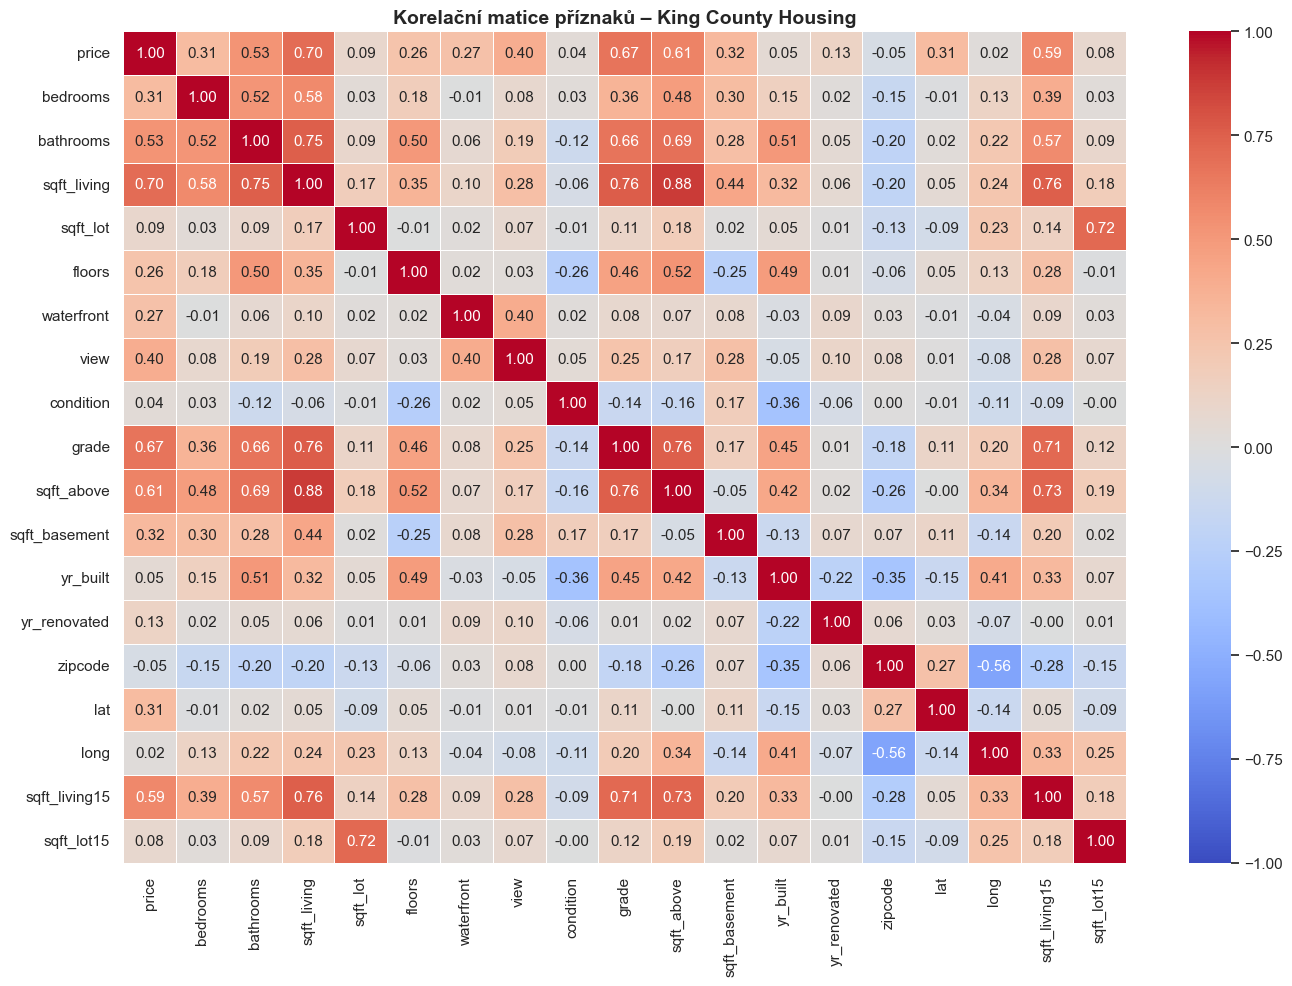

In [6]:
corr_matrix = housing_df.corr()
price_corr = corr_matrix['price'].sort_values(ascending=False)
print('Korelace s cenou (price) seřazeno sestupně:')
print(price_corr)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Korelační matice příznaků – King County Housing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(plots_dir / '01_correlation_matrix.png', dpi=300)
plt.show()

### Grafické ověření linearity pro top korelující proměnné

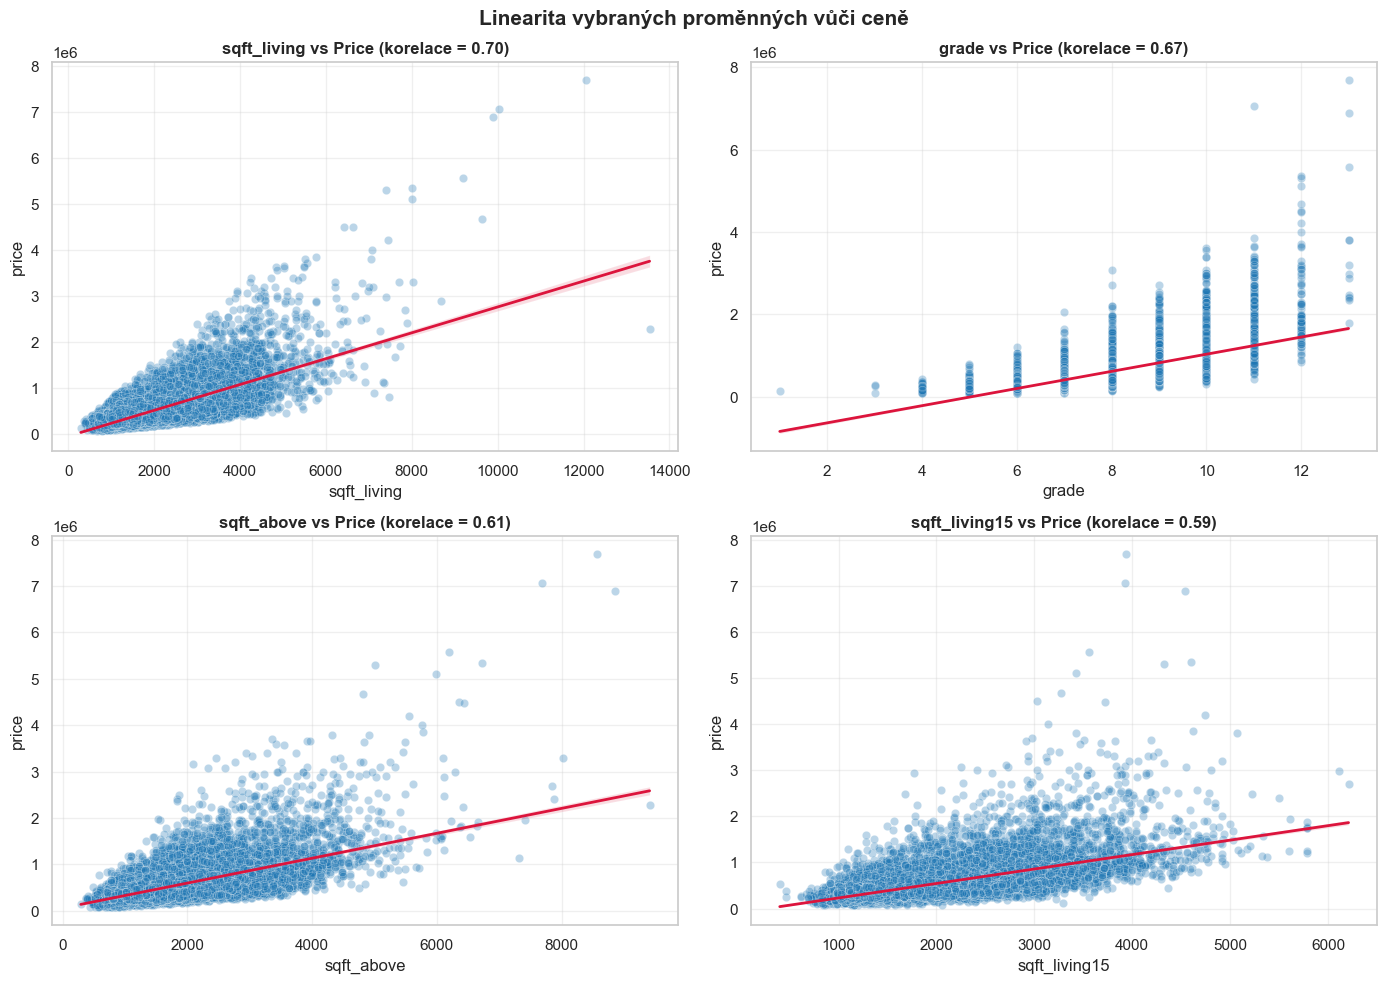

In [7]:
top_features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flatten(), top_features):
    sns.scatterplot(data=housing_df, x=feat, y='price', alpha=0.3, ax=ax, color='#1f77b4')
    sns.regplot(data=housing_df, x=feat, y='price', scatter=False, ax=ax, color='crimson', line_kws={'linewidth': 2})
    ax.set_title(f'{feat} vs Price (korelace = {corr_matrix.loc[feat, "price"]:.2f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Linearita vybraných proměnných vůči ceně', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(plots_dir / '02_scatter_features_vs_price.png', dpi=300)
plt.show()

## Krok 7: Detekce a odstranění odlehlých hodnot (Outliers)
Zkoumáme scatter ploty proměnných, u kterých se často vyskytují anomálie:
- `bedrooms`: hledáme extrémní hodnoty (např. 33 ložnic při ploše pouze 1620 sqft – typická chyba zadání).
- `sqft_living`: extrémně velké nemovitosti (nad 10 000 sqft), které mohou deformovat OLS regresní přímku.

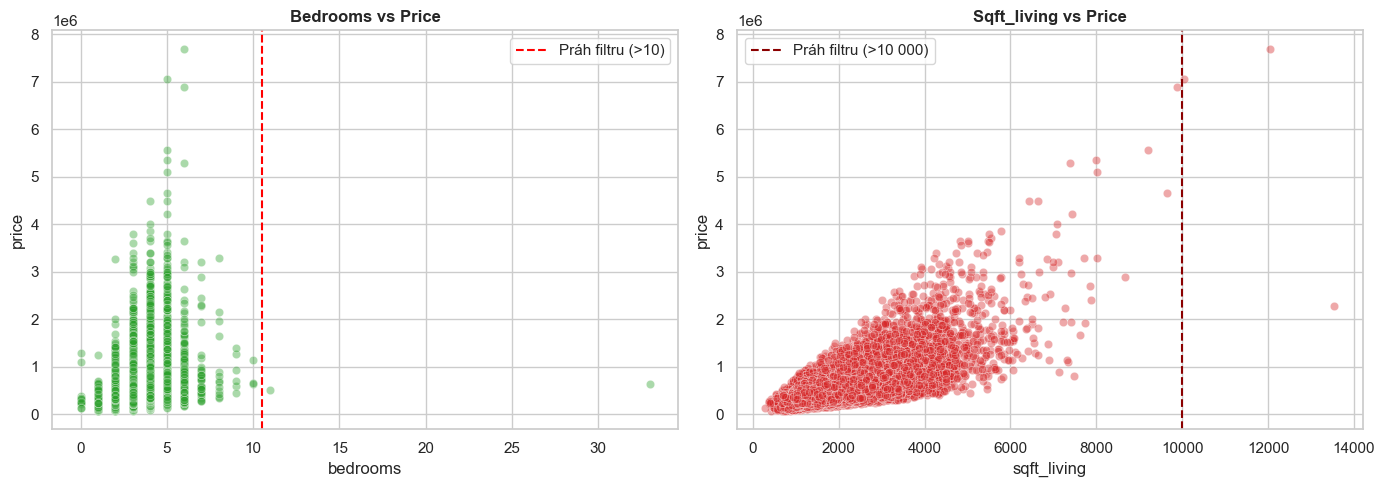

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=housing_df, x='bedrooms', y='price', alpha=0.4, ax=ax1, color='#2ca02c')
ax1.axvline(10.5, color='red', linestyle='--', label='Práh filtru (>10)')
ax1.set_title('Bedrooms vs Price', fontweight='bold')
ax1.legend()

sns.scatterplot(data=housing_df, x='sqft_living', y='price', alpha=0.4, ax=ax2, color='#d62728')
ax2.axvline(10000, color='darkred', linestyle='--', label='Práh filtru (>10 000)')
ax2.set_title('Sqft_living vs Price', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig(plots_dir / '03_outliers_detection_bedrooms_sqft.png', dpi=300)
plt.show()

### Odstranění identifikovaných odlehlých hodnot

In [9]:
# Filtrujeme zjevné překlepy a extrémní odlehlé hodnoty
price_cap = housing_df['price'].quantile(0.998)
clean_df = housing_df[
    (housing_df['bedrooms'] <= 10) &
    (housing_df['bedrooms'] > 0) &
    (housing_df['sqft_living'] <= 10000) &
    (housing_df['price'] <= price_cap)
].copy()

dropped = len(housing_df) - len(clean_df)
print(f'Původní počet řádků: {len(housing_df)}')
print(f'Odstraněno anomálií: {dropped} ({dropped / len(housing_df) * 100:.2f} %)')
print(f'Konečný počet řádků: {len(clean_df)}')

Původní počet řádků: 21613
Odstraněno anomálií: 60 (0.28 %)
Konečný počet řádků: 21553


## Krok 8: Rozdělení dat na trénovací a testovací sadu (Train/Test Split)

In [10]:
X = clean_df.drop(columns=['price'])
y = clean_df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Trénovací množina: X_train = {X_train.shape}, y_train = {y_train.shape}')
print(f'Testovací množina:  X_test = {X_test.shape}, y_test = {y_test.shape}')

Trénovací množina: X_train = (17242, 18), y_train = (17242,)
Testovací množina:  X_test = (4311, 18), y_test = (4311,)


## Krok 9 & 10: Trénování modelu `LinearRegression` a evaluace

In [11]:
lin_reg_raw = LinearRegression()
lin_reg_raw.fit(X_train, y_train)

y_pred_test_raw = lin_reg_raw.predict(X_test)
r2_raw = lin_reg_raw.score(X_test, y_test)
rmse_raw = np.sqrt(mean_squared_error(y_test, y_pred_test_raw))
mae_raw = mean_absolute_error(y_test, y_pred_test_raw)

print(f'R2 skóre na testovací sadě (Raw): {r2_raw:.4f}')
print(f'RMSE na testovací sadě (Raw):     ${rmse_raw:,.2f}')
print(f'MAE na testovací sadě (Raw):      ${mae_raw:,.2f}')

R2 skóre na testovací sadě (Raw): 0.7118
RMSE na testovací sadě (Raw):     $175,320.77
MAE na testovací sadě (Raw):      $117,241.66


## Krok 11: Standardizace proměnných $X$ (`StandardScaler`) a porovnání $R^2$

> **DŮLEŽITÝ TEORETICKÝ POZNATEK:**  
> Proč je $R^2$ po standardizaci **matematicky identické** jako před standardizací?  
> Standardizace $z = (x - \mu) / \sigma$ je **lineární afinní transformace**. U analytického řešení OLS $(X^T X)^{-1} X^T y$ se váhy $w$ pouze algebraicky přepočítají ($w_{scaled} = w_{raw} \cdot \sigma$), ale predikce $\hat{y}$ i rozptyl chyb zůstávají exaktně stejné.  
> **Standardizace je však klíčová pro:**
> 1. Správné porovnání důležitosti příznaků (Feature Importance).
> 2. Přípravu na regularizovanou regresi (Ridge, Lasso), kde penalizace závisí na velikosti vah!

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_scaled, y_train)

y_pred_test_scaled = lin_reg_scaled.predict(X_test_scaled)
r2_scaled = lin_reg_scaled.score(X_test_scaled, y_test)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_test_scaled))
mae_scaled = mean_absolute_error(y_test, y_pred_test_scaled)

print(f'R2 skóre po standardizaci: {r2_scaled:.4f}')
print(f'Rozdíl (Scaled - Raw):     {r2_scaled - r2_raw:.2e} (v podstatě 0)')
print(f'RMSE po standardizaci:     ${rmse_scaled:,.2f}')
print(f'MAE po standardizaci:      ${mae_scaled:,.2f}')

R2 skóre po standardizaci: 0.7118
Rozdíl (Scaled - Raw):     7.88e-15 (v podstatě 0)
RMSE po standardizaci:     $175,320.77
MAE po standardizaci:      $117,241.66


### Porovnání vah před a po standardizaci (Skutečná důležitost příznaků)

In [13]:
coef_df = pd.DataFrame({
    'Příznak': X.columns,
    'Surová váha (Raw)': lin_reg_raw.coef_,
    'Standardizovaná váha': lin_reg_scaled.coef_,
    'Absolutní vliv': np.abs(lin_reg_scaled.coef_)
}).sort_values(by='Absolutní vliv', ascending=False)

coef_df

,Příznak,Surová váha (Raw),Standardizovaná váha,Absolutní vliv
8,grade,96325.101023,112040.961952,112040.961952
14,lat,589510.904330,81657.852599,81657.852599
11,yr_built,-2552.325020,-74944.404747,74944.404747
2,sqft_living,86.954969,63280.426619,63280.426619
9,sqft_above,55.167862,58234.842774,58234.842774
6,view,51782.975006,38902.979559,38902.979559
5,waterfront,411623.156431,32772.723455,32772.723455
13,zipcode,-523.016500,-27958.744474,27958.744474
16,sqft_living15,41.054282,27922.060751,27922.060751
1,bathrooms,36370.136873,27596.063668,27596.063668


## Krok 12: Uložení připraveného datasetu do CSV

In [14]:
output_csv = data_dir / 'kc_house_data_preprocessed.csv'
clean_df.to_csv(output_csv, index=False)
print(f'Připravený dataset byl úspěšně uložen do: {output_csv}')

Připravený dataset byl úspěšně uložen do: data\kc_house_data_preprocessed.csv


## Krok 13: Vlastní analýza a moderní ML rozšíření (Stav k 09/2026)

### A. Diagnostika reziduí (Kontrola homoskedasticity a normality)

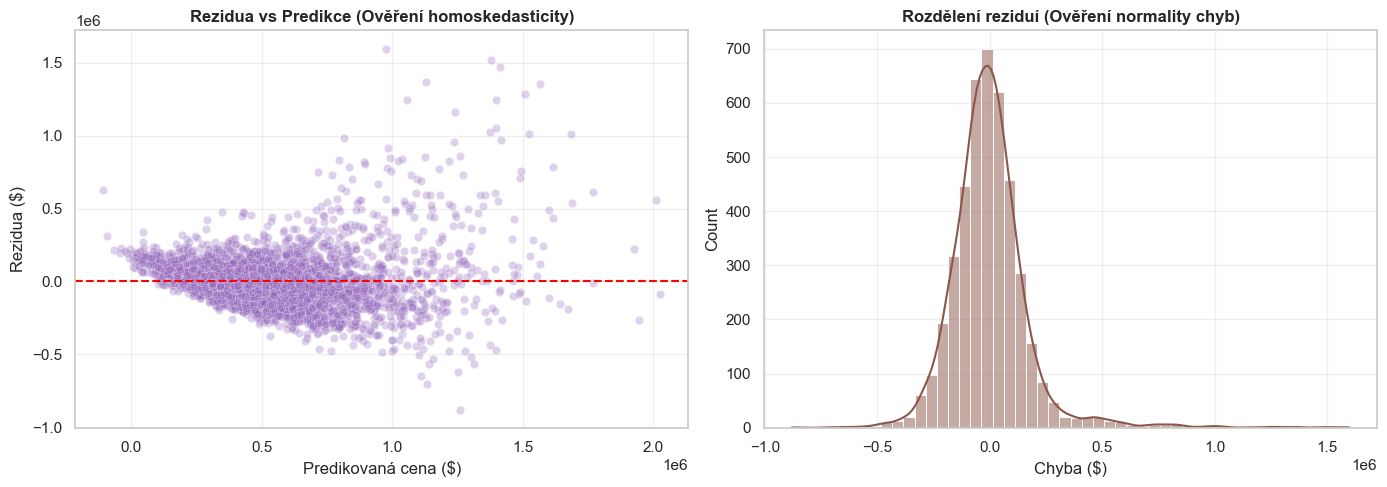

In [15]:
residuals = y_test - y_pred_test_scaled

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=y_pred_test_scaled, y=residuals, alpha=0.3, color='#9467bd', ax=ax1)
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax1.set_title('Rezidua vs Predikce (Ověření homoskedasticity)', fontweight='bold')
ax1.set_xlabel('Predikovaná cena ($)')
ax1.set_ylabel('Rezidua ($)')
ax1.grid(True, alpha=0.3)

sns.histplot(residuals, kde=True, ax=ax2, color='#8c564b', bins=50)
ax2.set_title('Rozdělení reziduí (Ověření normality chyb)', fontweight='bold')
ax2.set_xlabel('Chyba ($)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / '04_actual_vs_predicted_residuals.png', dpi=300)
plt.show()

### B. Log-transformace cílové proměnné (`TransformedTargetRegressor`)
Vzhledem k exponenciálnímu charakteru cen nemovitostí vede modelování v logaritmickém měřítku k přirozenějšímu chování chyb a výraznému snížení MAE.

In [16]:
log_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print(f'R2 skóre (Log-Transform): {r2_score(y_test, y_pred_log):.4f}')
print(f'RMSE (Log-Transform):     ${np.sqrt(mean_squared_error(y_test, y_pred_log)):,.2f}')
print(f'MAE (Log-Transform):      ${mean_absolute_error(y_test, y_pred_log):,.2f}')

R2 skóre (Log-Transform): 0.7152
RMSE (Log-Transform):     $174,287.56
MAE (Log-Transform):      $107,843.16


### C. Srovnání s moderním Gradient Boostingem (`HistGradientBoostingRegressor`)
Pro srovnání, jakého výkonu dosahuje moderní nelineární tabulární algoritmus bez nutnosti manuálního feature engineeringu.

In [17]:
hgb_model = HistGradientBoostingRegressor(random_state=42)
hgb_model.fit(X_train, y_train)
y_pred_hgb = hgb_model.predict(X_test)

print(f'R2 skóre (HistGradientBoosting): {r2_score(y_test, y_pred_hgb):.4f}')
print(f'RMSE (HistGradientBoosting):     ${np.sqrt(mean_squared_error(y_test, y_pred_hgb)):,.2f}')
print(f'MAE (HistGradientBoosting):      ${mean_absolute_error(y_test, y_pred_hgb):,.2f}')

R2 skóre (HistGradientBoosting): 0.9019
RMSE (HistGradientBoosting):     $102,305.53
MAE (HistGradientBoosting):      $64,574.60


### D. Časová analýza & Time-Aware ML: Vliv data prodeje a reálný Time-Split

V zadání kurzu bylo datum prodeje (`date`) vyřazeno. V praxi to ale způsobuje:
1. **Data Leakage:** Náhodné promíchání domů z celého roku učí model predikovat minulost na základě budoucnosti.
2. **Ignorování sezónnosti:** V zimě (leden/únor) padají ceny o cca 8–10 % oproti jarnímu nákupnímu boomu (duben/květen).

Níže otestujeme:
1. **Model s časovým trendem** (`days_since_start`) a měsícem prodeje (`month`).
2. **Reálný Time-Split:** Natrénování na transakcích z roku 2014 (14 587 domů) a otestování na budoucích transakcích z roku 2015 (6 966 domů).
3. **Past lineární extrapolace:** Proč OLS selhává a Gradient Boosting vítězí.

In [18]:
# Doplňující experiment: Time-Aware ML a Time-Based Split
raw_df_with_date = pd.read_csv(raw_data_path)
clean_with_date = clean_df.copy()
clean_with_date['dt'] = pd.to_datetime(raw_df_with_date.loc[clean_df.index, 'date'].str[:8])
min_date = clean_with_date['dt'].min()
clean_with_date['days_since_start'] = (clean_with_date['dt'] - min_date).dt.days
clean_with_date['month'] = clean_with_date['dt'].dt.month

time_features = list(X.columns) + ['days_since_start', 'month']
X_time = clean_with_date[time_features]

# 1. Náhodný split s časovými příznaky
X_tr_t, X_te_t, _, _ = train_test_split(X_time, y, test_size=0.2, random_state=42)
ols_time_rand = LinearRegression().fit(X_tr_t, y_train)
y_pred_ols_time_rand = ols_time_rand.predict(X_te_t)
trend_coef = ols_time_rand.coef_[time_features.index('days_since_start')]

print(f"--- NÁHODNÝ SPLIT (Random Split) ---")
print(f"OLS s časem: R2 = {r2_score(y_test, y_pred_ols_time_rand):.4f}, MAE = ${mean_absolute_error(y_test, y_pred_ols_time_rand):,.0f}")
print(f"Odhadnutý denní růst trhu (trend): +${trend_coef:.2f}/den (cca +${trend_coef*365:,.0f}/rok)")

# 2. Reálný Time-Split: Trénink 2014, Testování 2015
split_date = pd.to_datetime('2015-01-01')
mask_tr = clean_with_date['dt'] < split_date
mask_te = clean_with_date['dt'] >= split_date

y_tr_split = clean_with_date.loc[mask_tr, 'price']
y_te_split = clean_with_date.loc[mask_te, 'price']

ols_base_time = LinearRegression().fit(clean_with_date.loc[mask_tr, X.columns], y_tr_split)
ols_time_time = LinearRegression().fit(clean_with_date.loc[mask_tr, time_features], y_tr_split)
hgb_time_time = HistGradientBoostingRegressor(random_state=42).fit(clean_with_date.loc[mask_tr, time_features], y_tr_split)

pred_base_time = ols_base_time.predict(clean_with_date.loc[mask_te, X.columns])
pred_time_time = ols_time_time.predict(clean_with_date.loc[mask_te, time_features])
pred_hgb_time = hgb_time_time.predict(clean_with_date.loc[mask_te, time_features])

print(f"\n--- REÁLNÝ ČASOVÝ SPLIT (Trénink < 2015, Test >= 2015) ---")
print(f"1. OLS Baseline (bez času):     R2 = {r2_score(y_te_split, pred_base_time):.4f}, MAE = ${mean_absolute_error(y_te_split, pred_base_time):,.0f}")
print(f"2. OLS s časem (extrapolace):    R2 = {r2_score(y_te_split, pred_time_time):.4f}, MAE = ${mean_absolute_error(y_te_split, pred_time_time):,.0f} <-- Past extrapolace!")
print(f"3. Gradient Boosting (HGB):      R2 = {r2_score(y_te_split, pred_hgb_time):.4f}, MAE = ${mean_absolute_error(y_te_split, pred_hgb_time):,.0f} <-- Stabilní vládce času")

--- NÁHODNÝ SPLIT (Random Split) ---
OLS s časem: R2 = 0.7124, MAE = $117,206
Odhadnutý denní růst trhu (trend): +$97.09/den (cca +$35,438/rok)



--- REÁLNÝ ČASOVÝ SPLIT (Trénink < 2015, Test >= 2015) ---
1. OLS Baseline (bez času):     R2 = 0.6883, MAE = $123,105
2. OLS s časem (extrapolace):    R2 = 0.5046, MAE = $173,730 <-- Past extrapolace!
3. Gradient Boosting (HGB):      R2 = 0.8768, MAE = $71,652 <-- Stabilní vládce času
